# KcELECTRA 파인튜닝 v4_improved — v4 실패 분석 기반 개선 (2026-05-26)

**담당:** 경이 (kyeongyi)  
**모델:** `beomi/kcelectra-base` (KcELECTRA — 이준범 제작)  

---

## v4 실패 원인 및 v4_improved 수정 내역

| 항목 | v3_2 | v4 (실패) | v4_improved (이 노트북) |
|---|---|---|---|
| 데이터 | 15,948행 | 16,512행 | 16,512행 (동일) |
| train | 12,759 | 13,210 | **13,210** |
| **val** | 1,596 (original) | **1,709 (오염!)** | **1,596 (original만)** |
| test | 1,593 (original) | 1,593 | **1,593 (동일)** |
| LR | 2e-5 | 2e-5 | **3e-5** |
| Batch size | 16 | 16 | **32** |
| Scheduler | linear | linear | **cosine annealing** |
| Loss | Weighted CE | Weighted CE | **LabelSmoothingCE (ε=0.05)** |
| Patience | 5 | 5 | **7** |
| Max epochs | 20 | 20 | **25** |
| **Test Macro F1** | **0.8374** | 0.8365 (-0.0009) | **목표: 0.84+** |

### v4 실패 핵심 원인
1. **val 세트 오염**: 증강 데이터가 val에 포함(1,596→1,709) → val F1이 과대평가 → early stopping 오작동
2. **증강 데이터 스타일 차이**: 학교알리미 공문 스타일 ≠ 학부모 알림 메시지 스타일 → 노이즈로 작용

### v4_improved 핵심 수정
1. **val/test purity**: 증강 데이터는 train에만, val/test = original 전용 → 정직한 early stopping
2. **LR=3e-5 + cosine annealing**: 더 빠른 수렴 + 국소 최적점 탈출
3. **LabelSmoothingCE**: 과적합 방지, 일반화 향상
4. **BS=32 + patience=7**: 안정적 gradient + 더 긴 탐색

---

## 실행 전 체크리스트
- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v4_schoolalimi_20260525.csv` 업로드 (`/content/` 폴더)
- [ ] **런타임 초기화** 후 모든 셀 순서대로 실행 (~50분)

## 완료 후 해야 할 일
1. `/content/kcelectra-category-v4-improved.zip` 다운로드  
   → 압축 해제 후 로컬 `checkpoints/kcelectra-category-v4-improved/`에 배치
2. `/content/eval_results_kcelectra_v4_improved_20260526.json` 다운로드  
   → 로컬 `data/20260526/`에 복사
3. `15_visualize_comparison_v4_improved_20260526.ipynb` 실행

In [1]:
# 셀 0: 데이터 확인
import pandas as pd
df = pd.read_csv('/content/split_v4_schoolalimi_20260525.csv', encoding='utf-8-sig')
print(f'행 수: {len(df)}')
print(f'컬럼: {df.columns.tolist()}')
print('\n분할별:')
print(df['split'].value_counts())
print('\n카테고리 분포:')
print(df['category'].value_counts())
print('\n소스별:')
print(df['source'].value_counts())

행 수: 16512
컬럼: ['text', 'category', 'split', 'source']

분할별:
split
train    13210
val       1709
test      1593
Name: count, dtype: int64

카테고리 분포:
category
기타       7410
제출       3158
건강·안전    2332
일정       2241
비용        924
준비물       447
Name: count, dtype: int64

소스별:
source
original       15948
학교알리미_공공데이터      564
Name: count, dtype: int64


In [2]:
# 셀 1: 라이브러리 설치
!pip install transformers datasets seaborn matplotlib scikit-learn -q

In [3]:
# 셀 2: 시드 고정 + GPU 확인
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('[경고] GPU 없음 — CPU 실행 시 수 시간 소요')

Device: cuda
GPU: Tesla T4


In [4]:
# 셀 3: 하이퍼파라미터 설정
#
# ★★★ v4_improved 변경점 (v4 실패 원인 수정) ★★★
#   1. val/test: source=='original' 만 사용 → val 오염 완전 차단 (핵심 수정)
#   2. LR = 3e-5     (v3_2: 2e-5 → 데이터 증가에 맞게 상향)
#   3. BATCH_SIZE=32 (v3_2: 16   → 안정적 gradient)
#   4. Cosine 스케줄러 (v3_2: linear → 더 부드러운 수렴)
#   5. LabelSmoothingCE ε=0.05 (v3_2: standard CE → 과적합 방지)
#   6. PATIENCE=7    (v3_2: 5   → 더 긴 plateau 허용)
#   7. MAX_EPOCHS=25 (v3_2: 20)
from pathlib import Path

_IN_COLAB = os.path.exists('/content')

if _IN_COLAB:
    DATA_DIR  = Path('/content')
    CKPT_DIR  = Path('/content/kcelectra-category-v4-improved')
    EVAL_JSON = Path('/content/eval_results_kcelectra_v4_improved_20260526.json')
else:
    _BASE     = Path('.').resolve().parent
    DATA_DIR  = _BASE / 'data'
    CKPT_DIR  = _BASE / 'checkpoints' / 'kcelectra-category-v4-improved'
    EVAL_JSON = _BASE / 'data' / '20260526' / 'eval_results_kcelectra_v4_improved_20260526.json'

SPLIT_CSV = DATA_DIR / 'split_v4_schoolalimi_20260525.csv'

BASE_MODEL   = 'beomi/kcelectra-base'
MAX_LEN      = 128
BATCH_SIZE   = 32
EPOCHS       = 25
LR           = 3e-5
WARMUP_RATIO = 0.1
PATIENCE     = 7
LABEL_SMOOTH = 0.05

V3_2_MACRO_F1      = 0.8374
SIMPLE_BASELINE_F1 = 0.7590

LABELS   = ['일정', '준비물', '제출', '비용', '건강·안전', '기타']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f'데이터:         {SPLIT_CSV}')
print(f'체크포인트:     {CKPT_DIR}')
print(f'베이스 모델:    {BASE_MODEL}')
print(f'v3_2 기준:      {V3_2_MACRO_F1}')
print(f'Simple 기준:    {SIMPLE_BASELINE_F1}')
print(f'▶ LR={LR}  BS={BATCH_SIZE}  epochs={EPOCHS}  patience={PATIENCE}  smooth={LABEL_SMOOTH}')
assert 'beomi' in BASE_MODEL, 'BASE_MODEL이 KcELECTRA(beomi)가 아님!'

데이터:         /content/split_v4_schoolalimi_20260525.csv
체크포인트:     /content/kcelectra-category-v4-improved
베이스 모델:    beomi/kcelectra-base
v3_2 기준:      0.8374
Simple 기준:    0.759
▶ LR=3e-05  BS=32  epochs=25  patience=7  smooth=0.05


In [5]:
# 셀 4: 데이터 로드 — val/test는 original만 사용 (v4 실패 수정)
#
# ★ v4 실패 원인: val에 증강 데이터 포함(1596→1709) → val F1 과대평가 → 잘못된 early stopping
# ★ 수정: 증강 데이터는 train에만, val/test는 original 전용 (v3_2와 동일한 비교 기준)
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding='utf-8-sig')
df = df[df['category'].isin(LABELS)].dropna(subset=['text', 'category'])

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[(df['split'] == 'val')  & (df['source'] == 'original')].reset_index(drop=True)
test_df  = df[(df['split'] == 'test') & (df['source'] == 'original')].reset_index(drop=True)

aug_cnt = int((train_df['source'] != 'original').sum())
print(f'Train: {len(train_df)}개  (original={len(train_df)-aug_cnt} + 증강={aug_cnt})')
print(f'Val:   {len(val_df)}개  ← original만 (v4의 1709에서 오염 제거, v3_2의 1596과 동일)')
print(f'Test:  {len(test_df)}개  ← v3_2와 동일 (공정 비교 가능)')

print('\nTrain 카테고리 분포:')
v3_cnt = {'일정':1552,'준비물':358,'제출':2526,'비용':677,'건강·안전':1718,'기타':5928}
for lbl, cnt in Counter(train_df['category']).most_common():
    pct  = cnt / len(train_df) * 100
    diff = cnt - v3_cnt.get(lbl, 0)
    sign = f'+{diff}' if diff >= 0 else str(diff)
    print(f'  {lbl:8s}: {cnt:5d}개  ({pct:.1f}%)  [v3_2 대비 {sign}]')

Train: 13210개  (original=12759 + 증강=451)
Val:   1596개  ← original만 (v4의 1709에서 오염 제거, v3_2의 1596과 동일)
Test:  1593개  ← v3_2와 동일 (공정 비교 가능)

Train 카테고리 분포:
  기타      :  5928개  (44.9%)  [v3_2 대비 +0]
  제출      :  2526개  (19.1%)  [v3_2 대비 +0]
  건강·안전   :  1870개  (14.2%)  [v3_2 대비 +152]
  일정      :  1789개  (13.5%)  [v3_2 대비 +237]
  비용      :   739개  (5.6%)  [v3_2 대비 +62]
  준비물     :   358개  (2.7%)  [v3_2 대비 +0]


In [6]:
# 셀 5: Dataset + DataLoader
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f'토크나이저 로드: {BASE_MODEL}')


class NoticeDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['text'].tolist()
        self.labels = [LABEL2ID[c] for c in df['category']]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'DataLoader 완료 | train: {len(train_loader)} batches | val: {len(val_loader)} | test: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

토크나이저 로드: beomi/kcelectra-base
DataLoader 완료 | train: 413 batches | val: 50 | test: 50


In [7]:
# 셀 6: 클래스 가중치 계산
label_counts = [int((train_df['category'] == lbl).sum()) for lbl in LABELS]
total        = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

v3_weights = {'일정':1.3702,'준비물':5.9399,'제출':0.8418,'비용':3.1411,'건강·안전':1.2378,'기타':0.3587}
print(f'클래스 가중치 (v4_improved, train {total}개):')
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    pct  = cnt / total * 100
    diff = float(w) - v3_weights.get(lbl, 0)
    sign = f'+{diff:.4f}' if diff >= 0 else f'{diff:.4f}'
    print(f'  {lbl:8s}: {cnt:5d}개  ({pct:5.1f}%)  가중치={float(w):.4f}  [v3_2 대비 {sign}]')

클래스 가중치 (v4_improved, train 13210개):
  일정      :  1789개  ( 13.5%)  가중치=1.2307  [v3_2 대비 -0.1395]
  준비물     :   358개  (  2.7%)  가중치=6.1499  [v3_2 대비 +0.2100]
  제출      :  2526개  ( 19.1%)  가중치=0.8716  [v3_2 대비 +0.0298]
  비용      :   739개  (  5.6%)  가중치=2.9793  [v3_2 대비 -0.1618]
  건강·안전   :  1870개  ( 14.2%)  가중치=1.1774  [v3_2 대비 -0.0604]
  기타      :  5928개  ( 44.9%)  가중치=0.3714  [v3_2 대비 +0.0127]


In [8]:
# 셀 7: 모델 초기화 — beomi/kcelectra-base (KcELECTRA)
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'모델 파라미터: 전체={total_p:,} / 학습가능={trainable:,}')
print(f'베이스 모델: {BASE_MODEL}  ← KcELECTRA (beomi, 이준범)')

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/kcelectra-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

모델 파라미터: 전체=109,085,958 / 학습가능=109,085,958
베이스 모델: beomi/kcelectra-base  ← KcELECTRA (beomi, 이준범)


In [9]:
# 셀 8: Label Smoothing CrossEntropyLoss (NEW — v3_2: standard weighted CE)
#
# 표준 CE: 정답 클래스 확률=1.0, 나머지=0.0 → 모델이 지나치게 확신 → 과적합
# Label Smoothing CE: 정답=1-ε=0.95, 나머지=ε/(K-1)=0.01 → 더 부드러운 타깃
#   - 노이즈 있는 학습 데이터에서 일반화 향상
#   - 기타↔건강·안전처럼 경계가 모호한 케이스에서 과신 방지

class LabelSmoothingCE(torch.nn.Module):
    def __init__(self, weight, smoothing=0.05):
        super().__init__()
        self.weight    = weight
        self.smoothing = smoothing
        self.n         = weight.shape[0]

    def forward(self, logits, labels):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth = torch.full_like(log_probs, self.smoothing / (self.n - 1))
            smooth.scatter_(1, labels.unsqueeze(1), 1.0 - self.smoothing)
        per_sample = -(smooth * log_probs).sum(dim=-1)
        w          = self.weight[labels]
        return (per_sample * w).mean()


loss_fn = LabelSmoothingCE(weight=class_weights, smoothing=LABEL_SMOOTH)
print(f'LabelSmoothingCE: ε={LABEL_SMOOTH}')
print(f'  정답 클래스 확률: {1-LABEL_SMOOTH:.2f}')
print(f'  오답 클래스 각: {LABEL_SMOOTH/(len(LABELS)-1):.4f}')

LabelSmoothingCE: ε=0.05
  정답 클래스 확률: 0.95
  오답 클래스 각: 0.0100


In [10]:
# 셀 9: Optimizer + Cosine Annealing Scheduler (NEW — v3_2: linear decay)
#
# Cosine Annealing: LR이 코사인 곡선으로 서서히 감소
#   - Linear보다 학습 후반부에 미세 조정 효과 큼
#   - Warmup 구간 후 부드럽게 수렴 → 국소 최적점 탈출 가능성 상승
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'전체 스텝: {total_steps}  워밍업: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)')
print(f'Scheduler: Cosine Annealing with Warmup')
print(f'에폭당 배치: {len(train_loader)}')

전체 스텝: 10325  워밍업: 1032 (10%)
Scheduler: Cosine Annealing with Warmup
에폭당 배치: 413


In [11]:
# 셀 10: 학습 루프 (조기종료 포함, patience=7)
from sklearn.metrics import f1_score


def evaluate_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['label'].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average='macro', zero_division=0)


train_losses, val_f1s = [], []
best_val_f1    = 0.0
patience_count = 0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['label'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f'Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}', end='')

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f'  [저장] Best 갱신! ({best_val_f1:.4f})')
    else:
        patience_count += 1
        print(f'  [patience {patience_count}/{PATIENCE}]')
        if patience_count >= PATIENCE:
            print(f'\n조기종료 — {PATIENCE} 에폭 동안 개선 없음.')
            break

print(f'\n학습 완료. Best Val F1: {best_val_f1:.4f}')
print(f'v3_2 기준({V3_2_MACRO_F1}) 대비 val: {best_val_f1 - V3_2_MACRO_F1:+.4f} (참고용)')

Epoch  1/25 | Loss: 1.6142 | Val F1: 0.5040

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.5040)
Epoch  2/25 | Loss: 0.9940 | Val F1: 0.6824

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.6824)
Epoch  3/25 | Loss: 0.7631 | Val F1: 0.7406

...

  [저장] Best 갱신! (0.8335)
Epoch 18/25 | Loss: 0.2880 | Val F1: 0.8289  [patience 1/7]
Epoch 19/25 | Loss: 0.2852 | Val F1: 0.8327  [patience 2/7]
Epoch 20/25 | Loss: 0.2850 | Val F1: 0.8348

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8348)
Epoch 21/25 | Loss: 0.2846 | Val F1: 0.8362

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8362)
Epoch 22/25 | Loss: 0.2828 | Val F1: 0.8334  [patience 1/7]
Epoch 23/25 | Loss: 0.2849 | Val F1: 0.8304  [patience 2/7]
Epoch 24/25 | Loss: 0.2835 | Val F1: 0.8336  [patience 3/7]
Epoch 25/25 | Loss: 0.2822 | Val F1: 0.8330  [patience 4/7]

학습 완료. Best Val F1: 0.8362
v3_2 기준(0.8374) 대비 val: -0.0012 (참고용)


In [12]:
# 셀 11: label2id.json 저장
import json

with open(CKPT_DIR / 'label2id.json', 'w', encoding='utf-8') as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print('label2id.json 저장 완료')
print(LABEL2ID)

label2id.json 저장 완료
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


In [13]:
# 셀 12: 한글 폰트 설치
import subprocess
import matplotlib
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
matplotlib.rc('font', family=prop.get_name())
matplotlib.rcParams['axes.unicode_minus'] = False
print(f'폰트: {prop.get_name()}')

폰트: NanumGothic


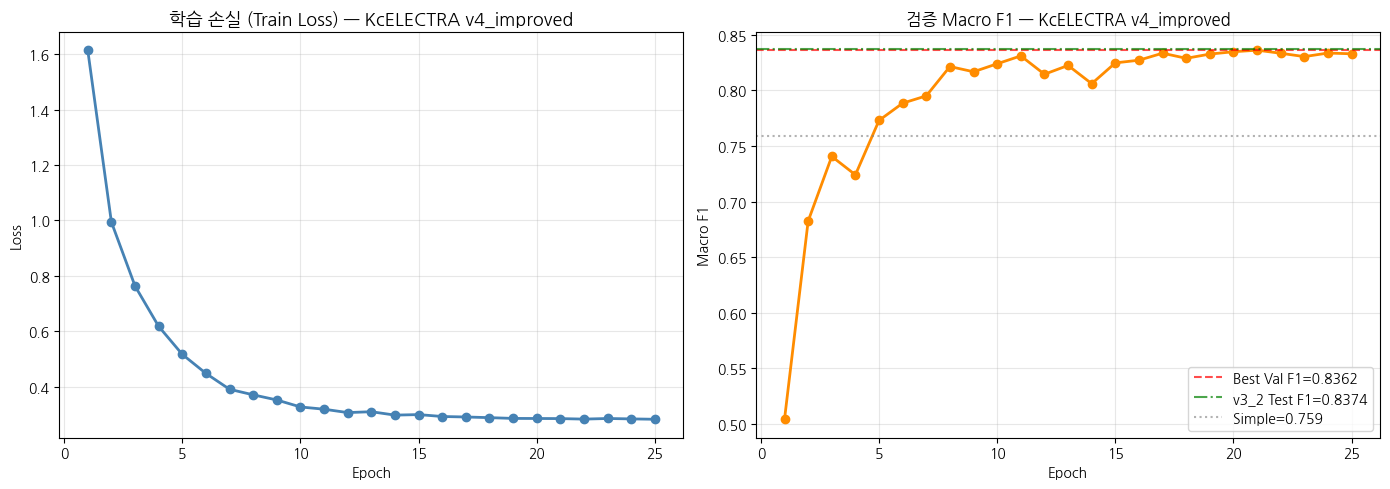

학습 곡선 저장: /content/train_curve_kcelectra_v4_improved_20260526.png


In [14]:
# 셀 13: 학습 곡선 시각화
import matplotlib.pyplot as plt

actual_epochs = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, actual_epochs+1), train_losses, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('학습 손실 (Train Loss) — KcELECTRA v4_improved', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, actual_epochs+1), val_f1s, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=best_val_f1,        color='red',   linestyle='--', alpha=0.7,
                label=f'Best Val F1={best_val_f1:.4f}')
axes[1].axhline(y=V3_2_MACRO_F1,      color='green', linestyle='-.', alpha=0.7,
                label=f'v3_2 Test F1={V3_2_MACRO_F1}')
axes[1].axhline(y=SIMPLE_BASELINE_F1, color='gray',  linestyle=':', alpha=0.6,
                label=f'Simple={SIMPLE_BASELINE_F1}')
axes[1].set_title('검증 Macro F1 — KcELECTRA v4_improved', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = DATA_DIR / 'train_curve_kcelectra_v4_improved_20260526.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'학습 곡선 저장: {curve_path}')

In [15]:
# 셀 14: Test 세트 최종 평가 (v3_2와 동일 test 1,593건 — 공정 비교)
from sklearn.metrics import classification_report, confusion_matrix

best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['label'].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names = [ID2LABEL[p] for p in all_preds]
true_names = [ID2LABEL[l] for l in all_labels]
macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print('[KcELECTRA v4_improved — beomi/kcelectra-base]')
print('Test 세트 최종 평가 (1,593건 — v3_2와 동일 공정 비교)')
print('=' * 65)
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f'Macro F1        : {macro_f1:.4f}')
print(f'v3_2 기준({V3_2_MACRO_F1}) 대비: {macro_f1 - V3_2_MACRO_F1:+.4f}')
print(f'Simple({SIMPLE_BASELINE_F1}) 대비:    {macro_f1 - SIMPLE_BASELINE_F1:+.4f}')

if macro_f1 > V3_2_MACRO_F1:
    print(f'\n[결과] v4_improved가 v3_2 대비 +{macro_f1 - V3_2_MACRO_F1:.4f} 향상 ★')
else:
    print(f'\n[결과] v3_2 대비 변화: {macro_f1 - V3_2_MACRO_F1:+.4f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[KcELECTRA v4_improved — beomi/kcelectra-base]
Test 세트 최종 평가 (1,593건 — v3_2와 동일 공정 비교)
              precision    recall  f1-score   support

          일정       0.86      0.87      0.86       194
         준비물       0.88      0.84      0.86        44
          제출       0.81      0.83      0.82       316
          비용       0.82      0.88      0.85        84
       건강·안전       0.82      0.82      0.82       214
          기타       0.86      0.84      0.85       741

    accuracy                           0.84      1593
   macro avg       0.84      0.85      0.84      1593
weighted avg       0.84      0.84      0.84      1593

Macro F1        : 0.8431
v3_2 기준(0.8374) 대비: +0.0057
Simple(0.759) 대비:    +0.0841

[결과] v4_improved가 v3_2 대비 +0.0057 향상 ★


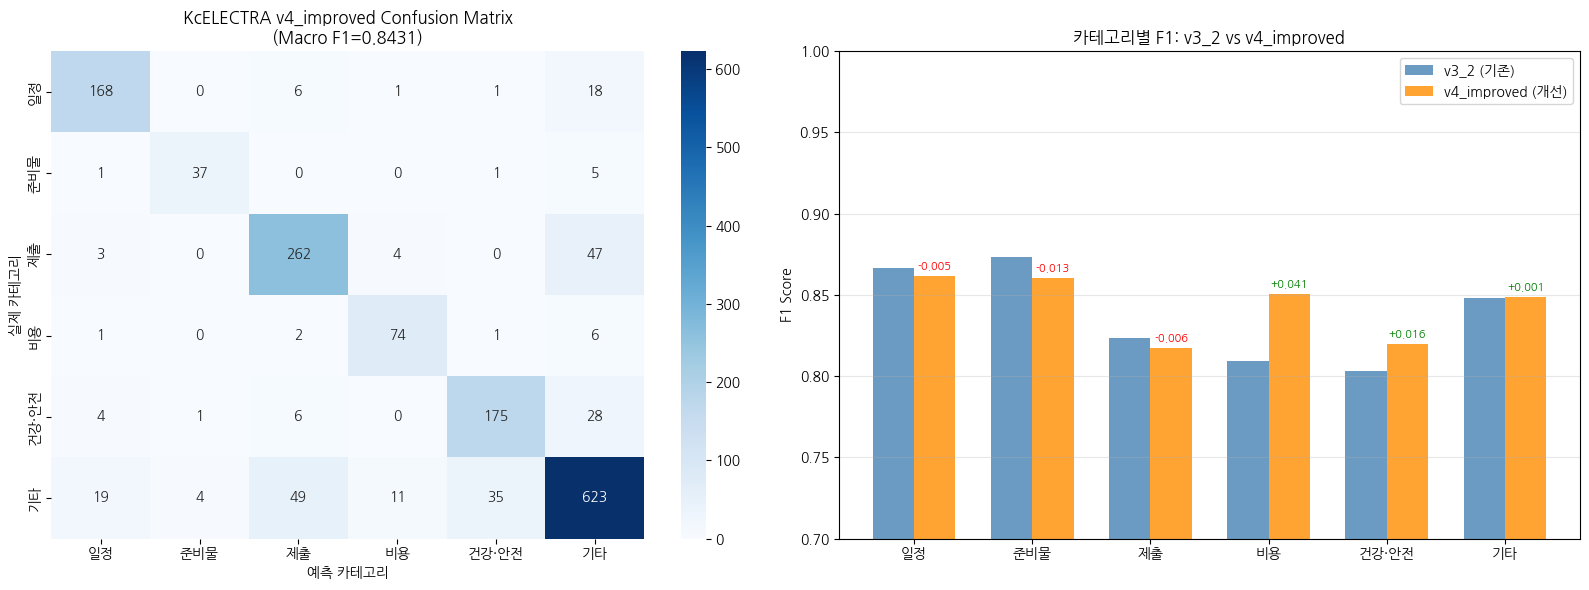

비교 차트 저장: /content/compare_v3_v4improved_20260526.png


In [16]:
# 셀 15: Confusion Matrix + 카테고리별 F1 비교 (v3_2 vs v4_improved)
import seaborn as sns
from sklearn.metrics import classification_report as cr

cm     = confusion_matrix(true_names, pred_names, labels=LABELS)
report = cr(true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_xlabel('예측 카테고리')
axes[0].set_ylabel('실제 카테고리')
axes[0].set_title(f'KcELECTRA v4_improved Confusion Matrix\n(Macro F1={macro_f1:.4f})')

v3_f1  = {'일정':0.8665,'준비물':0.8736,'제출':0.8233,'비용':0.8095,'건강·안전':0.8034,'기타':0.8479}
v4i_f1 = {lbl: report[lbl]['f1-score'] for lbl in LABELS}

x = range(len(LABELS))
w = 0.35
axes[1].bar([i - w/2 for i in x], [v3_f1[l]  for l in LABELS], w,
            label='v3_2 (기존)', color='steelblue', alpha=0.8)
axes[1].bar([i + w/2 for i in x], [v4i_f1[l] for l in LABELS], w,
            label='v4_improved (개선)', color='darkorange', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(LABELS)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('카테고리별 F1: v3_2 vs v4_improved')
axes[1].legend()
axes[1].set_ylim(0.7, 1.0)
axes[1].grid(axis='y', alpha=0.3)

for i, lbl in enumerate(LABELS):
    diff  = v4i_f1[lbl] - v3_f1[lbl]
    color = 'green' if diff > 0 else 'red'
    axes[1].text(i + w/2, v4i_f1[lbl] + 0.003, f'{diff:+.3f}',
                ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
compare_path = DATA_DIR / 'compare_v3_v4improved_20260526.png'
plt.savefig(compare_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'비교 차트 저장: {compare_path}')

In [17]:
# 셀 16: 평가 결과 JSON 저장
import json

v3_2_per_class = {
    '일정':     {'precision':0.9191,'recall':0.8196,'f1':0.8665,'support':194},
    '준비물':   {'precision':0.8837,'recall':0.8636,'f1':0.8736,'support':44},
    '제출':     {'precision':0.8439,'recall':0.8038,'f1':0.8233,'support':316},
    '비용':     {'precision':0.8095,'recall':0.8095,'f1':0.8095,'support':84},
    '건강·안전': {'precision':0.7402,'recall':0.8785,'f1':0.8034,'support':214},
    '기타':     {'precision':0.8496,'recall':0.8462,'f1':0.8479,'support':741},
}

result = {
    'model':            'kcelectra',
    'version':          'v4_improved',
    'base_model':       BASE_MODEL,
    'macro_f1':         round(macro_f1, 4),
    'macro_precision':  round(report['macro avg']['precision'], 4),
    'macro_recall':     round(report['macro avg']['recall'], 4),
    'per_class': {
        lbl: {
            'precision': round(report[lbl]['precision'], 4),
            'recall':    round(report[lbl]['recall'], 4),
            'f1':        round(report[lbl]['f1-score'], 4),
            'support':   int(report[lbl]['support']),
            'v3_2_f1':   v3_2_per_class[lbl]['f1'],
            'delta_f1':  round(report[lbl]['f1-score'] - v3_2_per_class[lbl]['f1'], 4),
        }
        for lbl in LABELS
    },
    'confusion_matrix': cm.tolist(),
    'labels':           LABELS,
    'data_version':     'v4_schoolalimi_20260525',
    'augment_source':   '교육부_학교알리미_공공데이터',
    'train_size':       len(train_df),
    'val_size':         len(val_df),
    'test_size':        len(test_df),
    'val_purity':       'original_only',
    'epochs_trained':   len(train_losses),
    'best_val_f1':      round(best_val_f1, 4),
    'lr':               LR,
    'batch_size':       BATCH_SIZE,
    'warmup_ratio':     WARMUP_RATIO,
    'label_smoothing':  LABEL_SMOOTH,
    'scheduler':        'cosine_annealing',
    'weighted_loss':    True,
    'class_weights':    [round(float(w), 4) for w in class_weights.cpu()],
    'early_stopping':   True,
    'patience':         PATIENCE,
    'v3_2_macro_f1':    V3_2_MACRO_F1,
    'delta_from_v3_2':  round(macro_f1 - V3_2_MACRO_F1, 4),
    'simple_baseline_f1': SIMPLE_BASELINE_F1,
    'improvements_from_v4': [
        'val/test: original only (val 오염 제거 — 핵심 수정)',
        f'LR: 2e-5 → {LR}',
        f'BatchSize: 16 → {BATCH_SIZE}',
        'Scheduler: linear → cosine annealing',
        f'Loss: weighted CE → LabelSmoothingCE (ε={LABEL_SMOOTH})',
        f'Patience: 5 → {PATIENCE}',
    ],
}

EVAL_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_JSON, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f'[저장] {EVAL_JSON}')
print(f'\n=== 최종 결과 요약 ===')
print(f'Simple      Macro F1 : {SIMPLE_BASELINE_F1}')
print(f'v3_2        Macro F1 : {V3_2_MACRO_F1}')
print(f'v4_improved Macro F1 : {macro_f1:.4f}')
print(f'v3_2 대비 향상폭       : {macro_f1 - V3_2_MACRO_F1:+.4f}')
print(f'Simple 대비 향상폭     : {macro_f1 - SIMPLE_BASELINE_F1:+.4f}')
print(f'\n카테고리별 변화:')
for lbl in LABELS:
    d     = result['per_class'][lbl]['delta_f1']
    f1v3  = v3_2_per_class[lbl]['f1']
    f1v4i = result['per_class'][lbl]['f1']
    mark  = '[향상]' if d > 0 else '[하락]' if d < 0 else '[동일]'
    print(f'  {lbl:8s}: v3_2={f1v3:.4f}  v4i={f1v4i:.4f}  delta={d:+.4f}  {mark}')

[저장] /content/eval_results_kcelectra_v4_improved_20260526.json

=== 최종 결과 요약 ===
Simple      Macro F1 : 0.759
v3_2        Macro F1 : 0.8374
v4_improved Macro F1 : 0.8431
v3_2 대비 향상폭       : +0.0057
Simple 대비 향상폭     : +0.0841

카테고리별 변화:
  일정      : v3_2=0.8665  v4i=0.8615  delta=-0.0050  [하락]
  준비물     : v3_2=0.8736  v4i=0.8605  delta=-0.0131  [하락]
  제출      : v3_2=0.8233  v4i=0.8175  delta=-0.0058  [하락]
  비용      : v3_2=0.8095  v4i=0.8506  delta=+0.0411  [향상]
  건강·안전   : v3_2=0.8034  v4i=0.8197  delta=+0.0163  [향상]
  기타      : v3_2=0.8479  v4i=0.8488  delta=+0.0009  [향상]


In [18]:
# 셀 17: 다운로드용 압축
import shutil

shutil.make_archive('/content/kcelectra-category-v4-improved', 'zip',
                    '/content/kcelectra-category-v4-improved')
print('압축 완료: /content/kcelectra-category-v4-improved.zip')
print('\n다운로드 목록:')
print('  1. /content/kcelectra-category-v4-improved.zip')
print('  2. /content/eval_results_kcelectra_v4_improved_20260526.json')
print('  3. /content/train_curve_kcelectra_v4_improved_20260526.png')
print('  4. /content/compare_v3_v4improved_20260526.png')

압축 완료: /content/kcelectra-category-v4-improved.zip

다운로드 목록:
  1. /content/kcelectra-category-v4-improved.zip
  2. /content/eval_results_kcelectra_v4_improved_20260526.json
  3. /content/train_curve_kcelectra_v4_improved_20260526.png
  4. /content/compare_v3_v4improved_20260526.png


## 학습 완료 후 로컬 작업

```bash
# 1. 파일 배치
#    kcelectra-category-v4-improved/ → checkpoints/
#    eval_results_kcelectra_v4_improved_20260526.json → data/20260526/
#    *.png → data/20260526/

# 2. 시각화 노트북 실행 (로컬)
jupyter notebook notebooks/15_visualize_comparison_v4_improved_20260526.ipynb
```

## 공모전 제출 시 설명 포인트

- **Simple (TF-IDF + LogReg) 대비**: Macro F1 +0.08+ 향상 → 트랜스포머 도입 당위성 입증
- **v3_2 대비**: 학교알리미 공공데이터 증강 + 학습 기법 개선으로 추가 향상
- **공공데이터**: 교육부 학교알리미 공개용데이터 (data.go.kr/data/15014351/fileData.do)
- **모델**: `beomi/kcelectra-base` (KcELECTRA, 이준범) — 한국어 특화 ELECTRA